In [293]:
import numpy as np
import matplotlib.pyplot as plt
import random
import csv

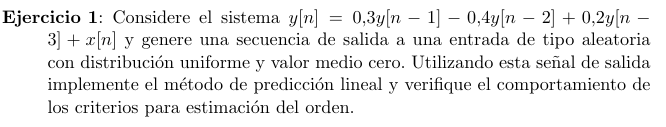

In [294]:
def uniforme(N = 10, seed = 42):
    rng = np.random.default_rng(seed)
    senial = rng.uniform(-1,1,N)
    return senial

orden = 10
entrada = uniforme(10000)
#print("Señal de entrada: ", entrada)

def sistema(y_1=0, y_2=0, y_3=0, x=0):
    return 0.3 * y_1 - 0.4 * y_2 + 0.2 * y_3 + x

salida = []
for i in range(len(entrada)):
    if i==0:
      valor_actual = sistema(0, 0, 0, entrada[i])
    if i==1:
      valor_actual = sistema(salida[i-1], 0, 0, entrada[i])
    if i==2:
      valor_actual = sistema(salida[i-1], salida[i-2], 0, entrada[i])
    if i>2:
      valor_actual = sistema(salida[i-1], salida[i-2], salida[i-3], entrada[i])
    salida.append(valor_actual)
salida = np.array(salida)
#print(f"Señal de salida: {salida}")

# Propuesta mia (no le gustó una mierda a GPT, pero da lo mismo)

def obtener_R(orden, salida):
    R = []
    for p in range(orden+1):
        r_s_i = 0
        for n in range(len(salida)):
            r_s_i += salida[n - p] * salida[n]
        R.append(r_s_i/len(salida))
    R = np.array(R)
    return R
R = obtener_R(orden, salida)

N = len(salida)
"""
R = []


# Propuesta GPT
for p in range(orden+1):
    r = 0
    for n in range(p, N):
        r += salida[n] * salida[n - p]
    R.append(r / N)  # normalización opcional pero recomendable

R = np.array(R)
"""

print(f"Vector correlación: {R}")

Vector correlación: [ 0.4056473   0.07044145 -0.12367867  0.01695119  0.06705171 -0.00945803
 -0.02716976  0.00721303  0.01101441 -0.00260024 -0.00315178]


In [ ]:
def obtener_matriz_coeficientes(orden, R):
    p = orden
    A = np.zeros((p,p))
    E = [R[0]]

    for i in range(0, p):
      elemento = 0
      for j in range(0, i):
          elemento += A[j,i-1] * R[i-j]
      k_i = -1/E[-1] * (R[i+1] + elemento)
      A[i,i] = k_i
      for j in range(0, i):
          A[j,i] = A[j,i-1] + k_i*A[i-j-1, i-1]
      E.append(E[-1]*(1 - k_i**2))

    #A = -A
    return A, E

#A = np.zeros((orden,orden))
#E = [R[0]]

A, E = obtener_matriz_coeficientes(orden, R)
print(A)

[[-0.17365197 -0.23364258 -0.30362324 -0.30419913 -0.30421781 -0.30426417
  -0.30425427 -0.3042529  -0.30425866 -0.30425602]
 [ 0.          0.34546462  0.39279352  0.39391021  0.39524669  0.39528085
   0.39526863  0.39527511  0.3952686   0.39526736]
 [ 0.          0.         -0.2025697  -0.20343288 -0.20602073 -0.2074745
  -0.2074638  -0.20747178 -0.20751312 -0.20751257]
 [ 0.          0.          0.          0.00284293  0.00484141  0.00763044
   0.0073395   0.00734668  0.00739596  0.00739227]
 [ 0.          0.          0.          0.         -0.00656964 -0.00871633
  -0.00816204 -0.00836485 -0.00840813 -0.00840437]
 [ 0.          0.          0.          0.          0.          0.00705642
   0.00662976  0.00701616  0.00823863  0.00823532]
 [ 0.          0.          0.          0.          0.          0.
   0.00140228  0.00110485 -0.00122421 -0.00113127]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.00097756  0.00277029  0.00259327]
 [ 0.          0.

In [296]:
def obtener_historial_error(A, salida):
    p = A.shape[0]
    historial_error = []
    for i in range(p):
        salida_propuesta = np.zeros_like(salida)
        for j in range(len(salida_propuesta)):
            for k in range(1,i+1): # El sistema va a tener i coeficientes para las salidas previas en cada iteración
                if j-k >= 0:
                    salida_propuesta[j] += salida[j-k]*A[k-1,i]
        historial_error.append(np.sum(np.abs(salida - salida_propuesta)))
    historial_error = np.array(historial_error)/len(historial_error)
    return historial_error

historial_error = []
for i in range(orden):
    salida_propuesta = np.zeros_like(salida)
    for j in range(len(salida_propuesta)):
        for k in range(1,i+1): # El sistema va a tener i coeficientes para las salidas previas en cada iteración
            if j-k >= 0:
                salida_propuesta[j] += salida[j-k]*A[k-1,i]
    historial_error.append(np.sum(np.abs(salida - salida_propuesta)))
historial_error = np.array(historial_error)/len(historial_error)
print(historial_error)

historial_error = obtener_historial_error(A, salida)

[534.19652138 560.45614108 643.2852174  642.15733771 641.93505964
 641.49482004 641.88620877 641.89075373 641.91256984 641.86425526]


In [297]:
def prd_ord_EPF(r_0,E,eps=1e-6):
    error = E[0]/r_0
    for i in range(1,len(E)):
        error_n = E[i]/r_0
        
        if ((1-error_n/error)<eps):
            return i
        error = error_n
    
    return len(E)-1

def prd_ord_Akaike(E, N, ventana="rectangular"):
    historial_Ip = []
    N_e = 1
    if ventana == "rectangular":
        N_e = N
    
    for i in range(len(E)):
        I_p = np.log(E[i]) + 2 * (i+1)/N_e
        historial_Ip.append(I_p)
    

    return historial_Ip

4
4


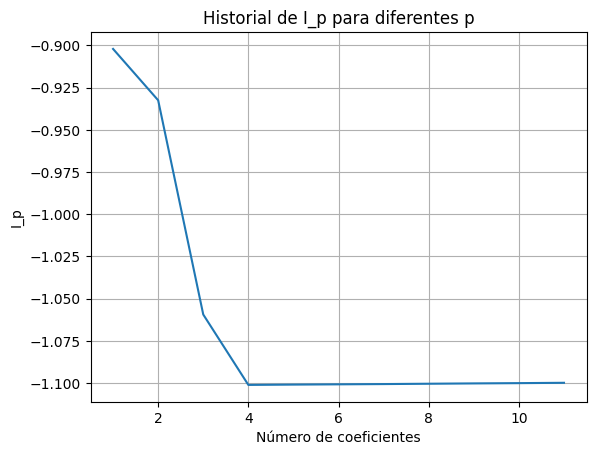

In [298]:
print(prd_ord_EPF(R[0],E,5e-3))
historial = prd_ord_Akaike(E,N)
print(np.argmin(historial) + 1)
plt.title("Historial de I_p para diferentes p")
plt.xlabel("Número de coeficientes")
plt.ylabel("I_p")
plt.grid()
plt.plot(np.arange(1, len(E)+1, 1), historial)

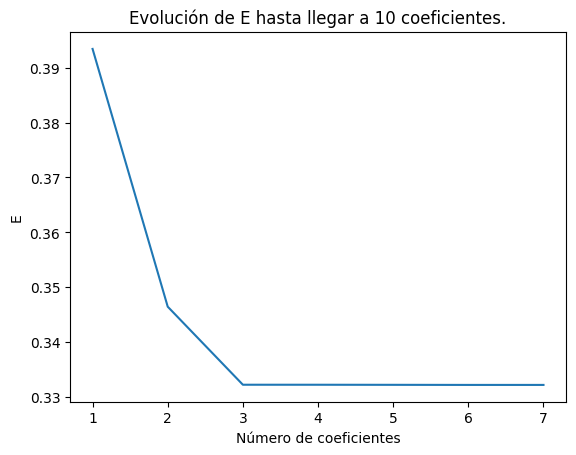

In [299]:
dom = np.arange(1,len(E)-3, 1)
plt.title(f'Evolución de E hasta llegar a {orden} coeficientes.')
plt.xlabel("Número de coeficientes")
plt.ylabel("E")
plt.plot(dom, E[1:-3])
plt.show()


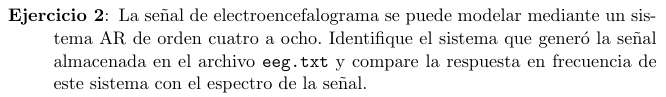

In [300]:
from scipy.fft import fft, fftfreq, ifft, fftshift

# Extraído de mis andanadas por SyS
def get_frec_dom(frecM, N):
  p = []
  pPos = np.linspace(0, frecM//2, N//2, endpoint=False)
  pNeg = np.linspace(-frecM//2, 0, N//2, endpoint=False)
  for i in pPos:
    p.append(i)
  for i in pNeg:
    p.append(i)
  return p

# Extraído de frecs.txt
frecM = 250

In [301]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

salida = cargar_dataset("PDS_TP1_signals/eeg.txt")
salida /= max(salida)
#idx = np.arange(0, salida.shape[0], 5)
#salida = salida[idx]
N = len(salida)
#salida -= np.mean(salida)
print(salida.shape)

(4100,)


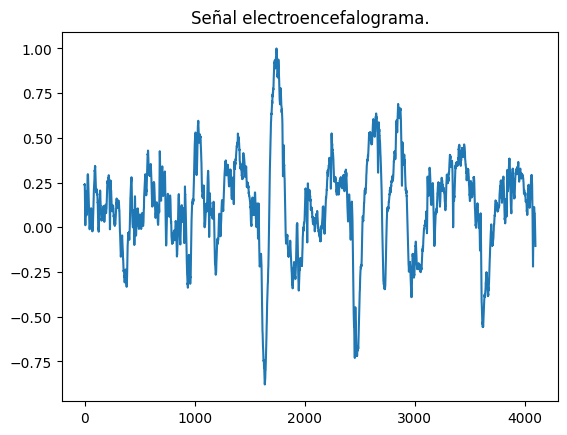

In [302]:
dom = np.arange(0,len(salida), 1)
plt.title("Señal electroencefalograma.")
plt.plot(dom, salida)
plt.show()

In [303]:
orden = 8
R = obtener_R(orden, salida)
A, E = obtener_matriz_coeficientes(orden, R)
historial_error = obtener_historial_error(A, salida)

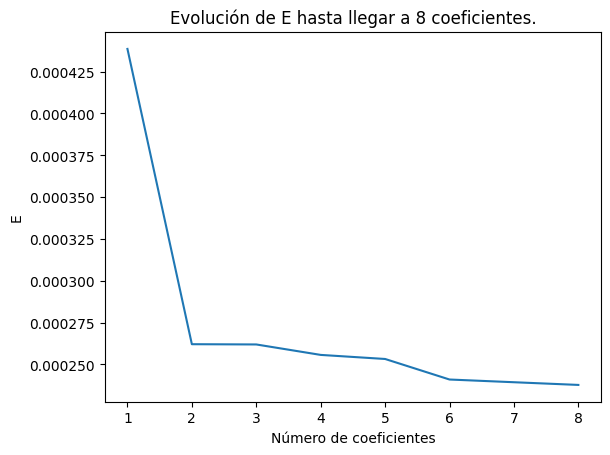

In [304]:
dom = np.arange(1,len(E), 1)
plt.title(f'Evolución de E hasta llegar a {orden} coeficientes.')
plt.xlabel("Número de coeficientes")
plt.ylabel("E")
plt.plot(dom, E[1:])
plt.show()

9


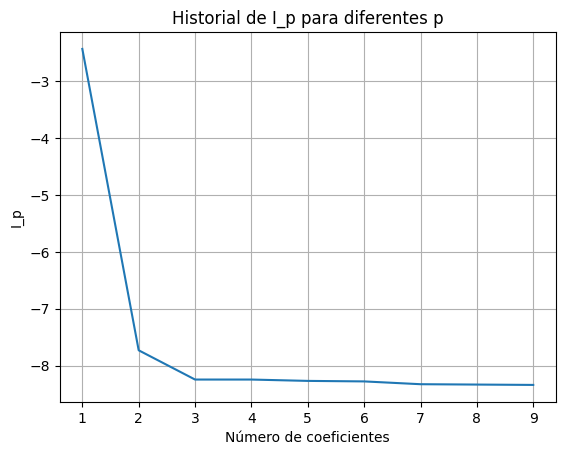

In [305]:
historial = prd_ord_Akaike(E,N)
print(np.argmin(historial) + 1)
plt.title("Historial de I_p para diferentes p")
plt.xlabel("Número de coeficientes")
plt.ylabel("I_p")
plt.grid()
plt.plot(np.arange(1, len(E)+1, 1), historial)

In [306]:
# OBTENIENDO LA RESPUESTA EN FRECUENCIA DEL SISTEMA

def respuesta_en_frecuencia(a, fs, N=512):
    w = np.linspace(-fs/2, fs/2, N)
    H = np.zeros(N, dtype=complex)

    z = np.exp(1j * 2*np.pi * w  / fs)
    denom = 1
    for k in range(len(a)):
        denom += a[k] * (z)**(-k)
    H = 1/denom

    imag = np.imag(H)
    real = np.real(H)
    amplitud = np.sqrt(real**2 + imag**2)
    amplitud /= max(amplitud)

    return w, amplitud

grado_seleccionado = orden - 1

w, H_abs = respuesta_en_frecuencia(A[:,grado_seleccionado][:grado_seleccionado], frecM)

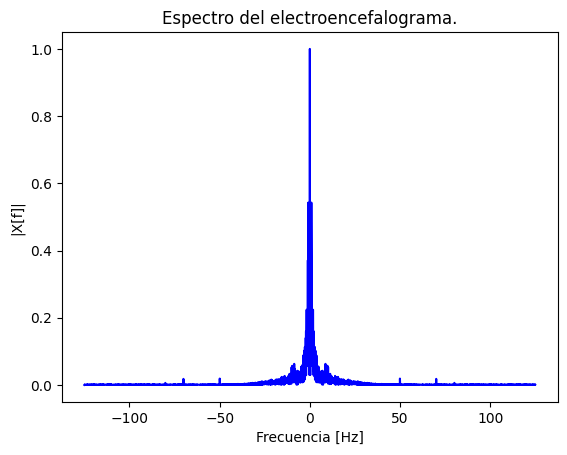

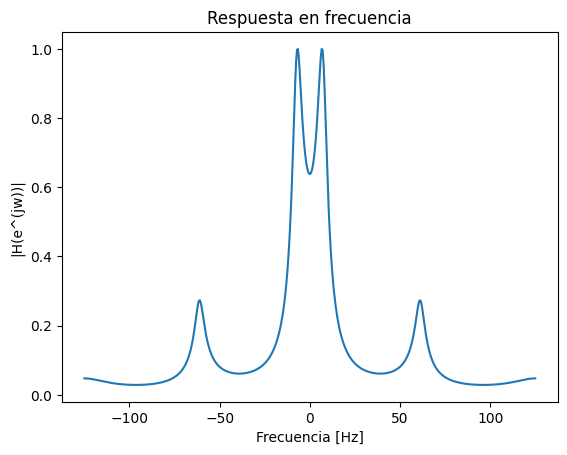

In [307]:
# OBTENIENDO EL ESPECTRO DE LA SEÑAL

S = fft(salida)
S /= len(S)

# Frecs
S_real = np.real(S)
S_im = np.imag(S)
S_norm = np.sqrt(S_real**2 + S_im**2)
S_norm = fftshift(S)

frecs = fftfreq(N, d=1/frecM)  # eje de frecuencias
frecs = fftshift(frecs)        # ordenar el eje: negativos a la izquierda

# dominio de frecuencias
plt.plot(frecs, np.abs(S_norm)/max(np.abs(S_norm)), label="DFT de la señal", color="blue")
plt.title("Espectro del electroencefalograma.")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[f]|")
plt.show()

plt.plot(w, H_abs, label="Modelo AR")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(e^(jw))|")
plt.title("Respuesta en frecuencia")
plt.show()